<!-- NINO26-CABECALHO v1 -->
# 4D — Alvos clusterizados e gate estatístico da hipótese

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `4D`  ·  **Hipótese:** HIP1

## Descritivo (por que este notebook existe)
Agrupa áreas com resposta parecida e testa formalmente a hipótese NEB seco/Sul úmido em El Niño — o gate da teleconexão (HIP1).

## Pergunta
Quais áreas respondem de modo parecido, em que lag, com que sentido seco/úmido e com que estabilidade? A evidência sustenta a hipótese?

## Desafio (hipótese a testar)
O gate precisa de FDR e da máscara EN/LN correta, sem corte temporal fixo e sem confundir média de anomalia com seca/extremo — usar índices de extremos.

## Metodologia (com referências)
Clusterização de perfis, lag por sinal e gate com estabilidade temporal; extremos por SPI/SPEI/ETCCDI em vez da média (Grimm & Tedeschi, 2009; Cai et al., 2020; Vicente-Serrano et al., 2010).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_4D01_mapa_clusters_pixels_nativos", fase=4, bloco="D",
                 titulo=..., descricao=..., hipotese="HIP1",
                 notebook="notebooks/fase4/4D_clusters_alvo.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase4/<codigo>.png + numeric-tables/fase4/<codigo>/
```

| Código | Figura (`figures/fase4/<código>.png`) | Numeric-table (`numeric-tables/fase4/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_4D01_mapa_clusters_pixels_nativos` | `Fig_4D01_mapa_clusters_pixels_nativos.png` | `Fig_4D01_mapa_clusters_pixels_nativos/` | mapa de clusters descritivos |
| `Fig_4D02_perfis_clusters_fdr` | `Fig_4D02_perfis_clusters_fdr.png` | `Fig_4D02_perfis_clusters_fdr/` | perfis FDR dos clusters |
| `Fig_4D03_gate_multialvo_eventos` | `Fig_4D03_gate_multialvo_eventos.png` | `Fig_4D03_gate_multialvo_eventos/` | síntese do gate multialvo por evento |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

In [1]:
SEED = 42
MIN_SIGNIFICANT_PROFILES = 2


In [2]:
import os, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
for candidate in (ROOT, ROOT/'src'):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))
from scripts.notebook_run_viewer import audit_phase4_outputs, load_phase4_table

STATS = ROOT/'data/processed/parquet/statistics'
ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip() or None
if ENSO_TYPE not in {None, 'el_nino', 'la_nina'}:
    raise ValueError(f'NINO26_ENSO_TYPE invÃ¡lido: {ENSO_TYPE!r}')
SCOPE_SUFFIX = f'_{ENSO_TYPE}' if ENSO_TYPE else ''
FIGS = ROOT/'data/processed/figures/fase4'/(ENSO_TYPE or '')
HYPOTHESIS_SUMMARY = STATS/f'phase4D_native_hypothesis_summary{SCOPE_SUFFIX}.csv'
GATE_EVENT_JACKKNIFE = STATS/f'phase4D_native_gate_event_jackknife{SCOPE_SUFFIX}.csv'
CLUSTER_RANKING = STATS/f'phase4D_native_cluster_ranking{SCOPE_SUFFIX}.csv'
F4D_OUTPUTS = [
    STATS/f'phase4D_native_clusters_pixels{SCOPE_SUFFIX}.parquet',
    STATS/f'phase4D_native_cluster_profiles{SCOPE_SUFFIX}.csv',
    CLUSTER_RANKING,
    GATE_EVENT_JACKKNIFE,
    HYPOTHESIS_SUMMARY,
    STATS/f'phase4D_native_target_coverage{SCOPE_SUFFIX}.csv',
]

RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    from scripts.run_fase4d_targets import main as run4d
    run_args = ['--seed', str(SEED), '--min-significant-profiles', str(MIN_SIGNIFICANT_PROFILES)]
    if ENSO_TYPE:
        run_args.extend(['--enso-type', ENSO_TYPE])
    run4d(run_args)
else:
    print('Modo viewer: validando numeric-tables F4D existentes.')


Modo viewer: validando numeric-tables F4D existentes.


## Tabelas, gate multi-alvo e figuras auditáveis


In [3]:
audit_4d, run_id_4d = audit_phase4_outputs(
    F4D_OUTPUTS, expected_stage='F4D', expected_enso_type=ENSO_TYPE
)
display(audit_4d)
if run_id_4d is None:
    print('F4D canônica ausente ou inválida; nenhuma conclusão é exibida.')
else:
    print({'analysis_run_id': run_id_4d, 'artifacts_validated': len(F4D_OUTPUTS)})
    summary = load_phase4_table(HYPOTHESIS_SUMMARY)
    gate = load_phase4_table(GATE_EVENT_JACKKNIFE)
    ranking = load_phase4_table(CLUSTER_RANKING)
    display(summary)
    display(gate)
    display(ranking)


,artifact,run_id,stage,selection_contract,valid,problems
0,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,
1,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,
2,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,
3,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,
4,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,
5,C:\DEV\NINO26\data\processed\parquet\statistic...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,F4D,,True,


{'analysis_run_id': 'F4D_20260713T191800Z_4422ba2d_5142b6cf_7_845974_120c32', 'artifacts_validated': 6}


,regiao,tipo_enso_fonte,fase_fonte_em_t_menos_lag,n_targets,n_targets_support,n_target_families,min_event_stability,max_q_confirmatory,max_p_primary_precip_field,n_target_families_support,...,cluster_min_significant_profiles,target_build_id,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,f4d_runner_sha256,lag_analysis_module_sha256
0,Nordeste,el_nino,crescimento,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
1,Nordeste,el_nino,decaimento,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
2,Nordeste,el_nino,genese,5,0,4,0.833333,0.849503,0.955,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
3,Nordeste,el_nino,pico,5,0,4,1.000000,0.125978,0.925,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
4,Nordeste,la_nina,crescimento,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
5,Nordeste,la_nina,decaimento,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
6,Nordeste,la_nina,genese,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
7,Nordeste,la_nina,pico,5,0,4,NaN,NaN,NaN,0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9

,id_unidade,regiao,condicao_fonte,tipo_enso_fonte,fase_fonte_em_t_menos_lag,variavel_pacifico,target_chirps,target_label,target_family,lag_sem_selecionado_F4C,...,cluster_min_significant_profiles,target_build_id,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,f4d_runner_sha256,lag_analysis_module_sha256
0,regiao_centro_oeste,Centro-Oeste,el_nino_genese,el_nino,genese,nino34_ssta,precip_robust_z,weekly precipitation anomaly,weekly_total_precipitation,68.0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
1,regiao_centro_oeste,Centro-Oeste,el_nino_genese,el_nino,genese,nino34_ssta,spi_gamma_3m_weekly_origin,SPI 3-month weekly origin,accumulated_meteorological_drought,68.0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
2,regiao_centro_oeste,Centro-Oeste,el_nino_genese,el_nino,genese,nino34_ssta,r95p_weekly_robust_z,R95p weekly anomaly,heavy_rainfall_extremes,68.0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
3,regiao_centro_oeste,Centro-Oeste,el_nino_genese,el_nino,genese,nino34_ssta,r99p_weekly_robust_z,R99p weekly anomaly,heavy_rainfall_extremes,68.0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
4,regiao_centro_oeste,Centro-Oeste,el_nino_genese,el_nino,genese,nino34_ssta,cdd_within_week_robust_z,dry-spell anomaly,dry_spell_persistence,68.0,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,regiao_nordeste,Nordeste,la_nina_decaimento,la_nina,decaimento,nino34_ssta,precip_robust_z,weekly precipitation anomaly,weekly_total_precipitation,NaN,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
196,regiao_nordeste,Nordeste,la_nina_decaimento,la_nina,decaimento,nino34_ssta,s

,cluster,n_pixels,latitude_media,longitude_media,regiao_predominante,silhueta_amostra,abs_r_fdr_medio,prioridade_descritiva,grid_hash_sha256,analysis_run_id,...,cluster_min_significant_profiles,target_build_id,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,f4d_runner_sha256,lag_analysis_module_sha256
0,3,1417,-10.561662,-48.958980,Nordeste,0.146379,0.341064,1,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
1,2,1227,-4.655155,-46.615220,Nordeste,0.146379,0.339410,2,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
2,0,1307,-21.739193,-54.080433,Sul,0.146379,0.328535,3,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...
3,1,6736,-9.844084,-54.649420,Norte,0.146379,0.307161,4,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4D_20260713T191800Z_4422ba2d_5142b6cf_7_84597...,...,2,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,cb1a7aec5e216838d693aee38dafa8a00ca4f524746cf8...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...


Uma área colorida não constitui significância. O suporte exige direção física, FDR confirmatório, significância de campo e estabilidade ao retirar cada evento inteiro.


Fig_4D01_mapa_clusters_pixels_nativos.png


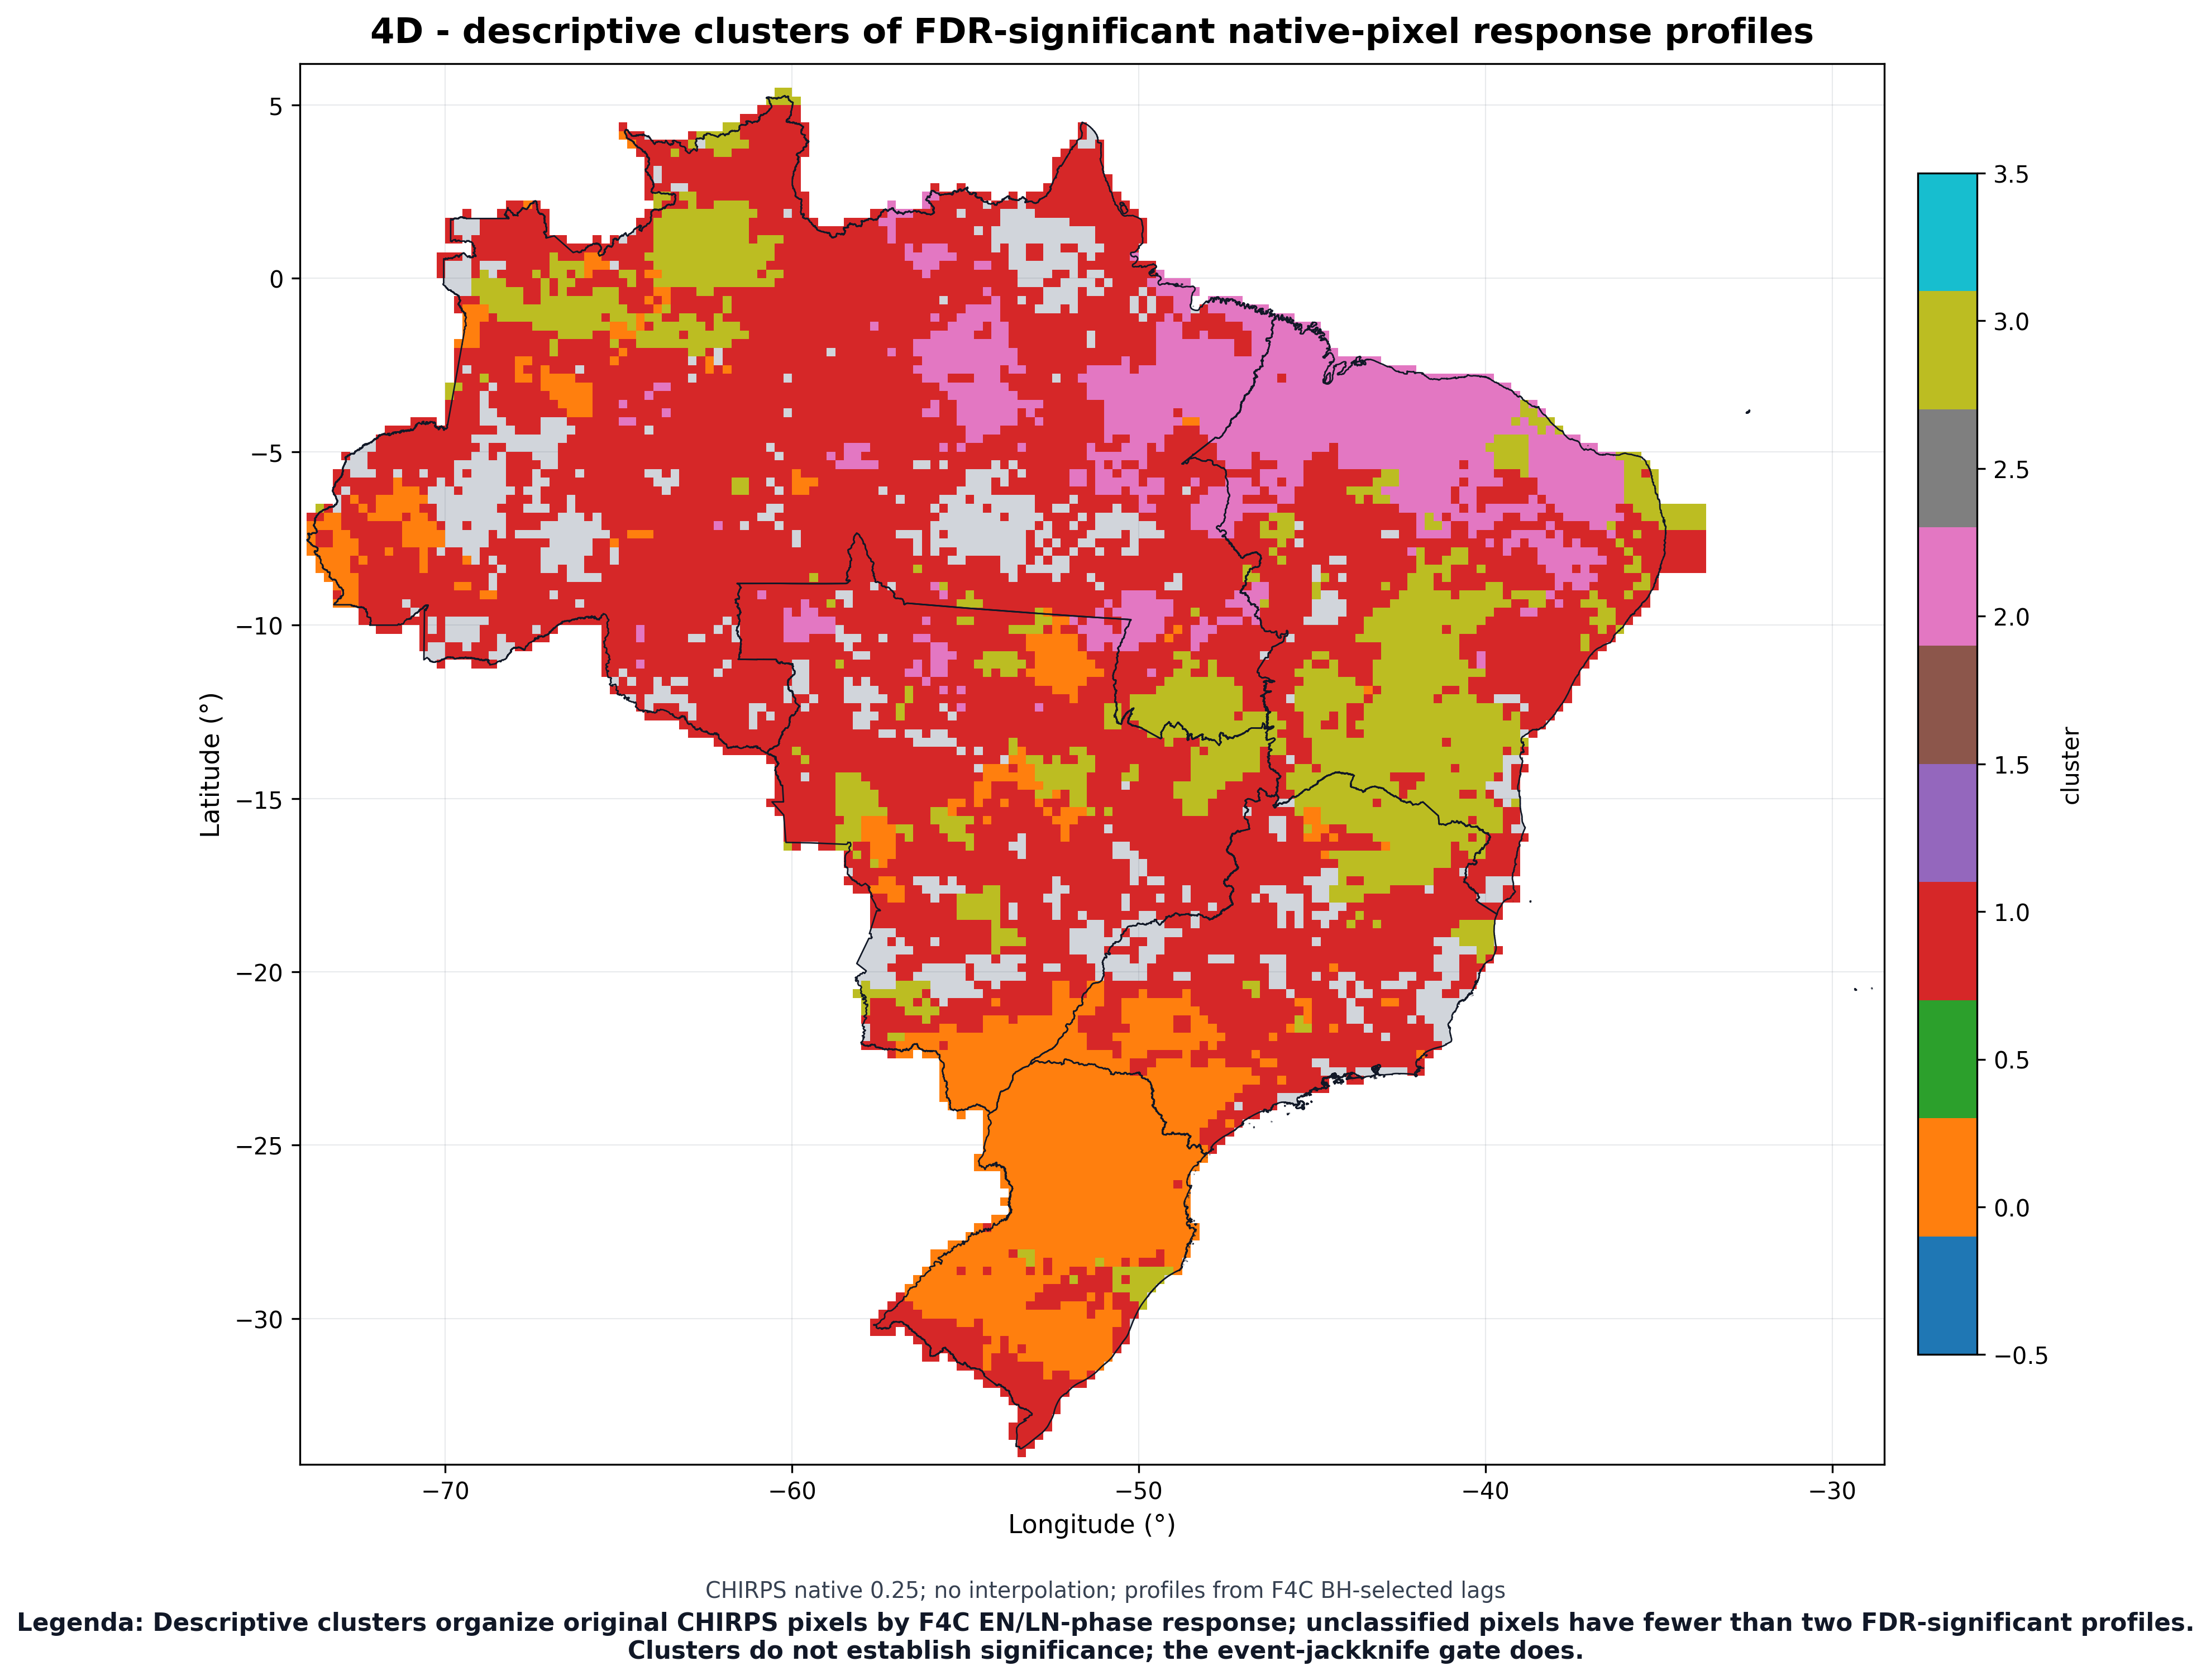

Fig_4D02_perfis_clusters_fdr.png


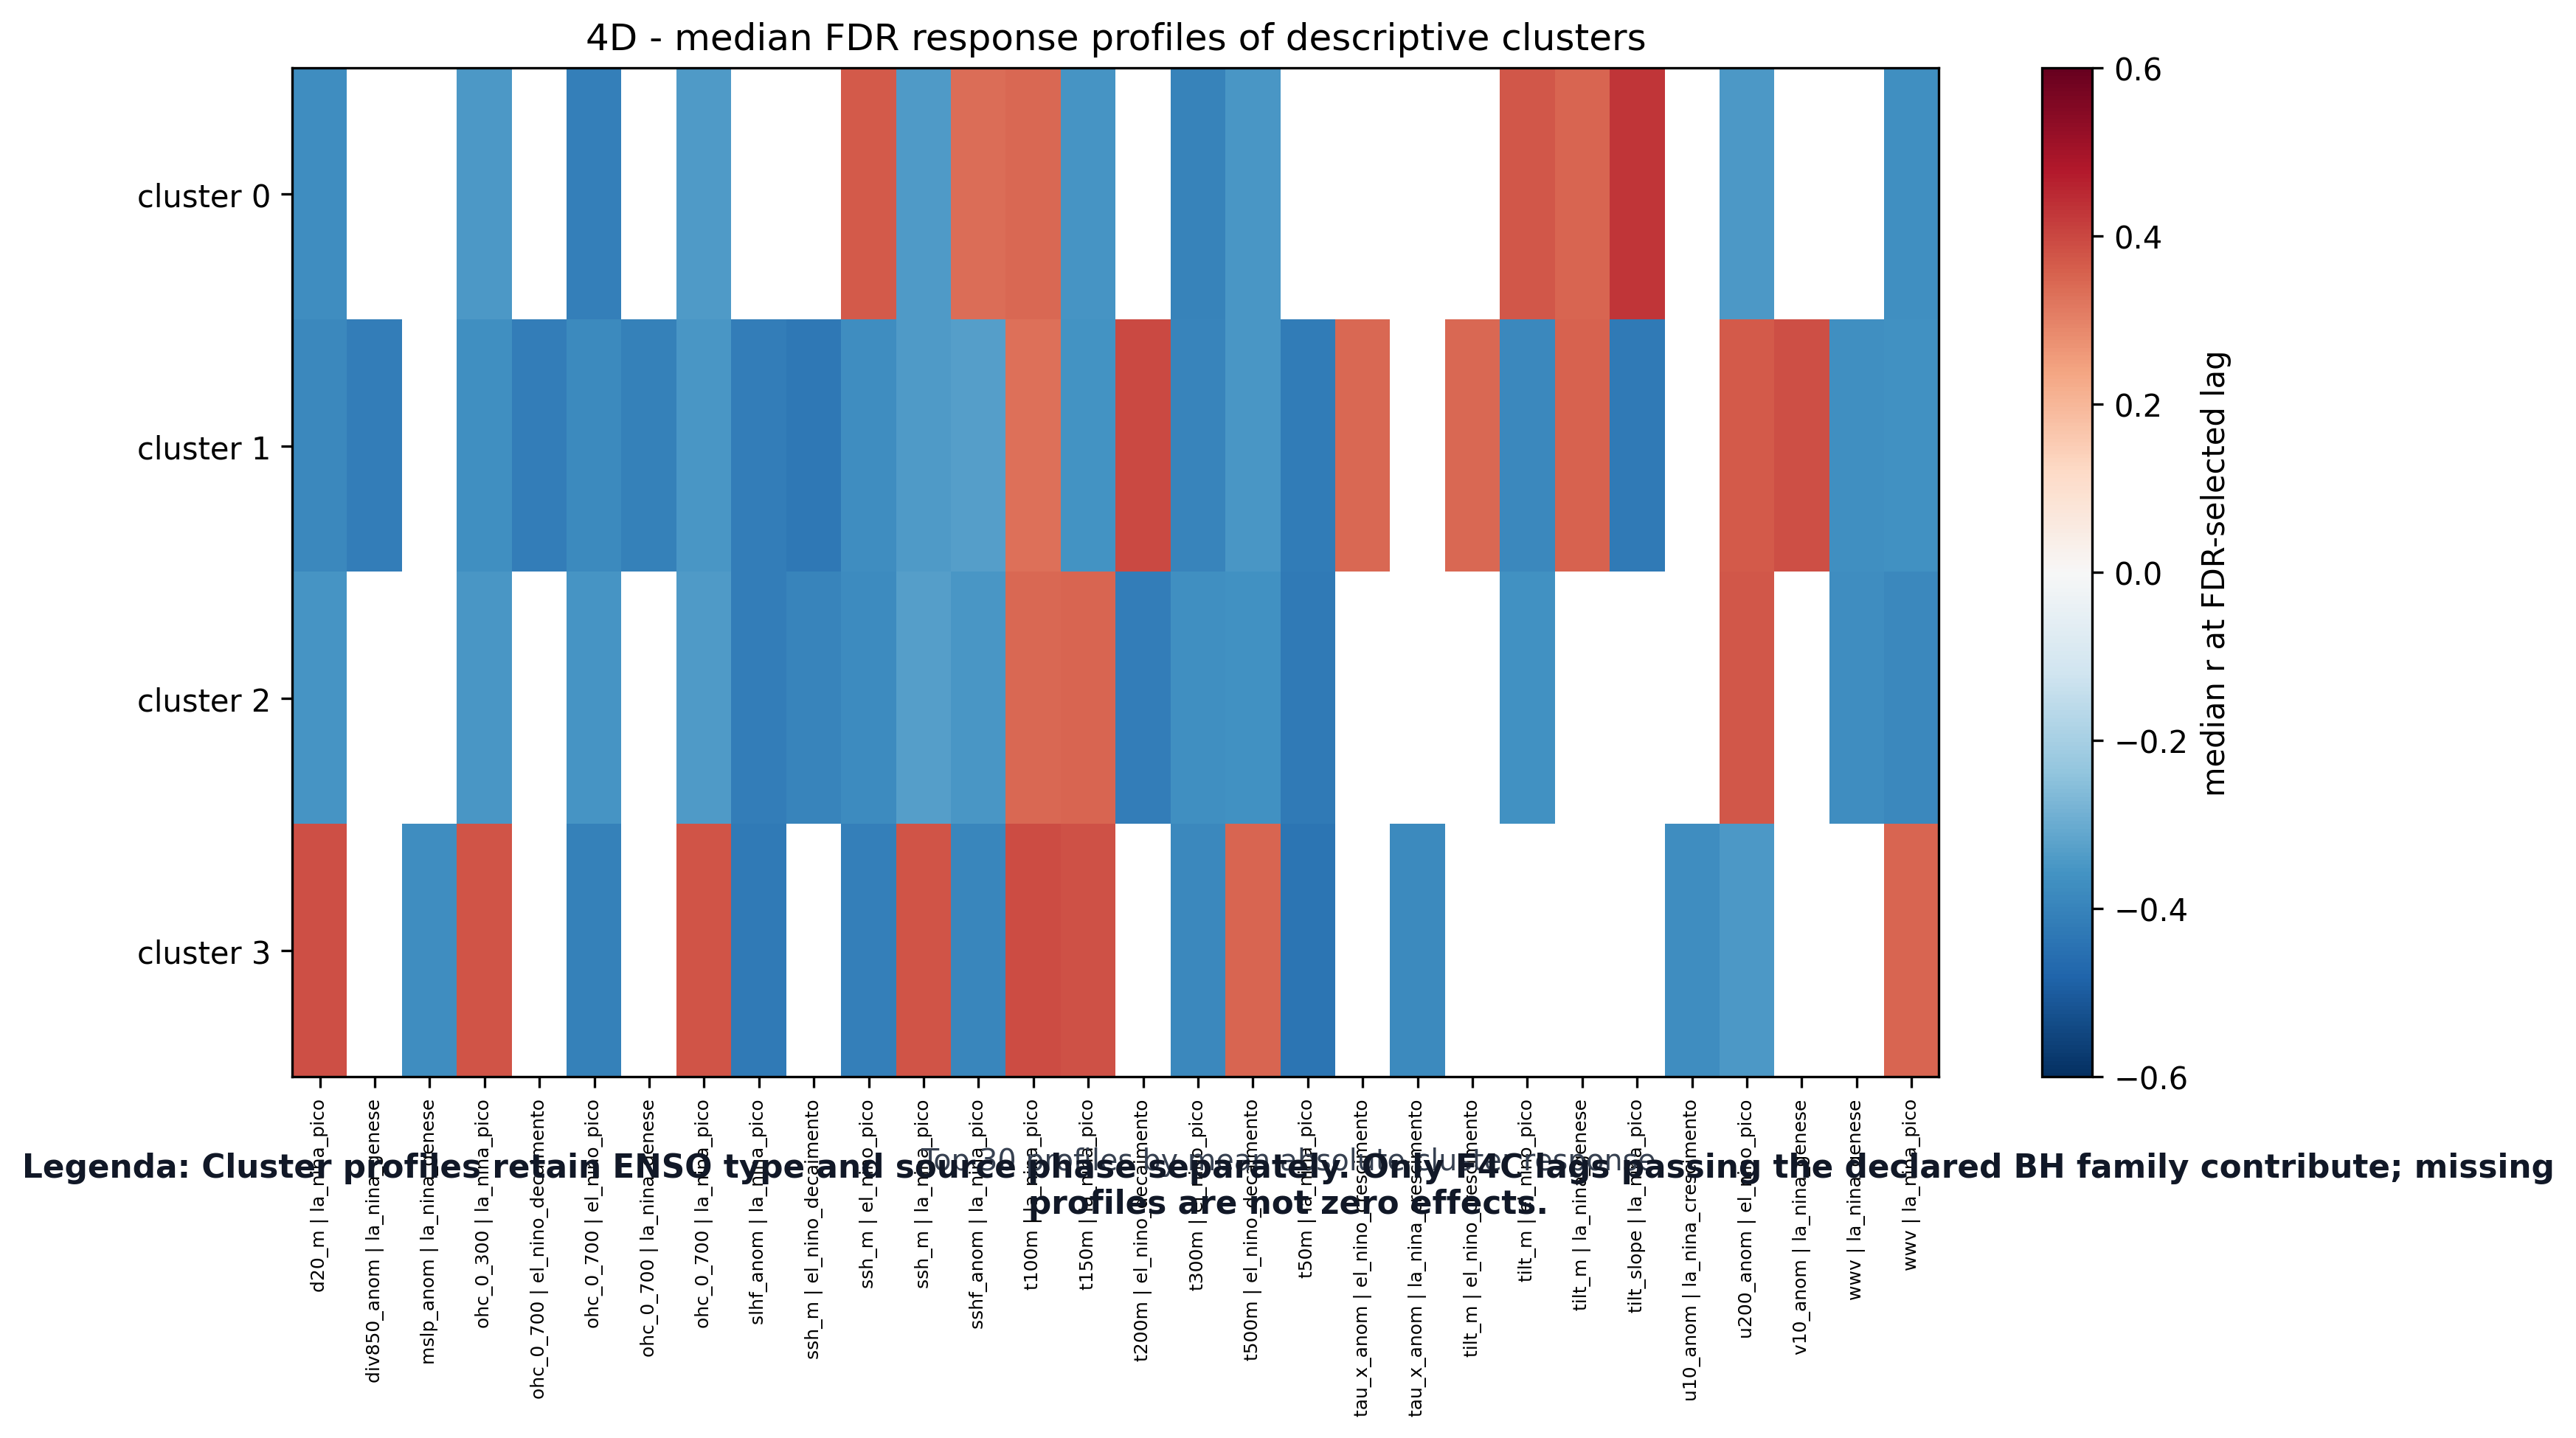

Fig_4D03_gate_multialvo_eventos.png


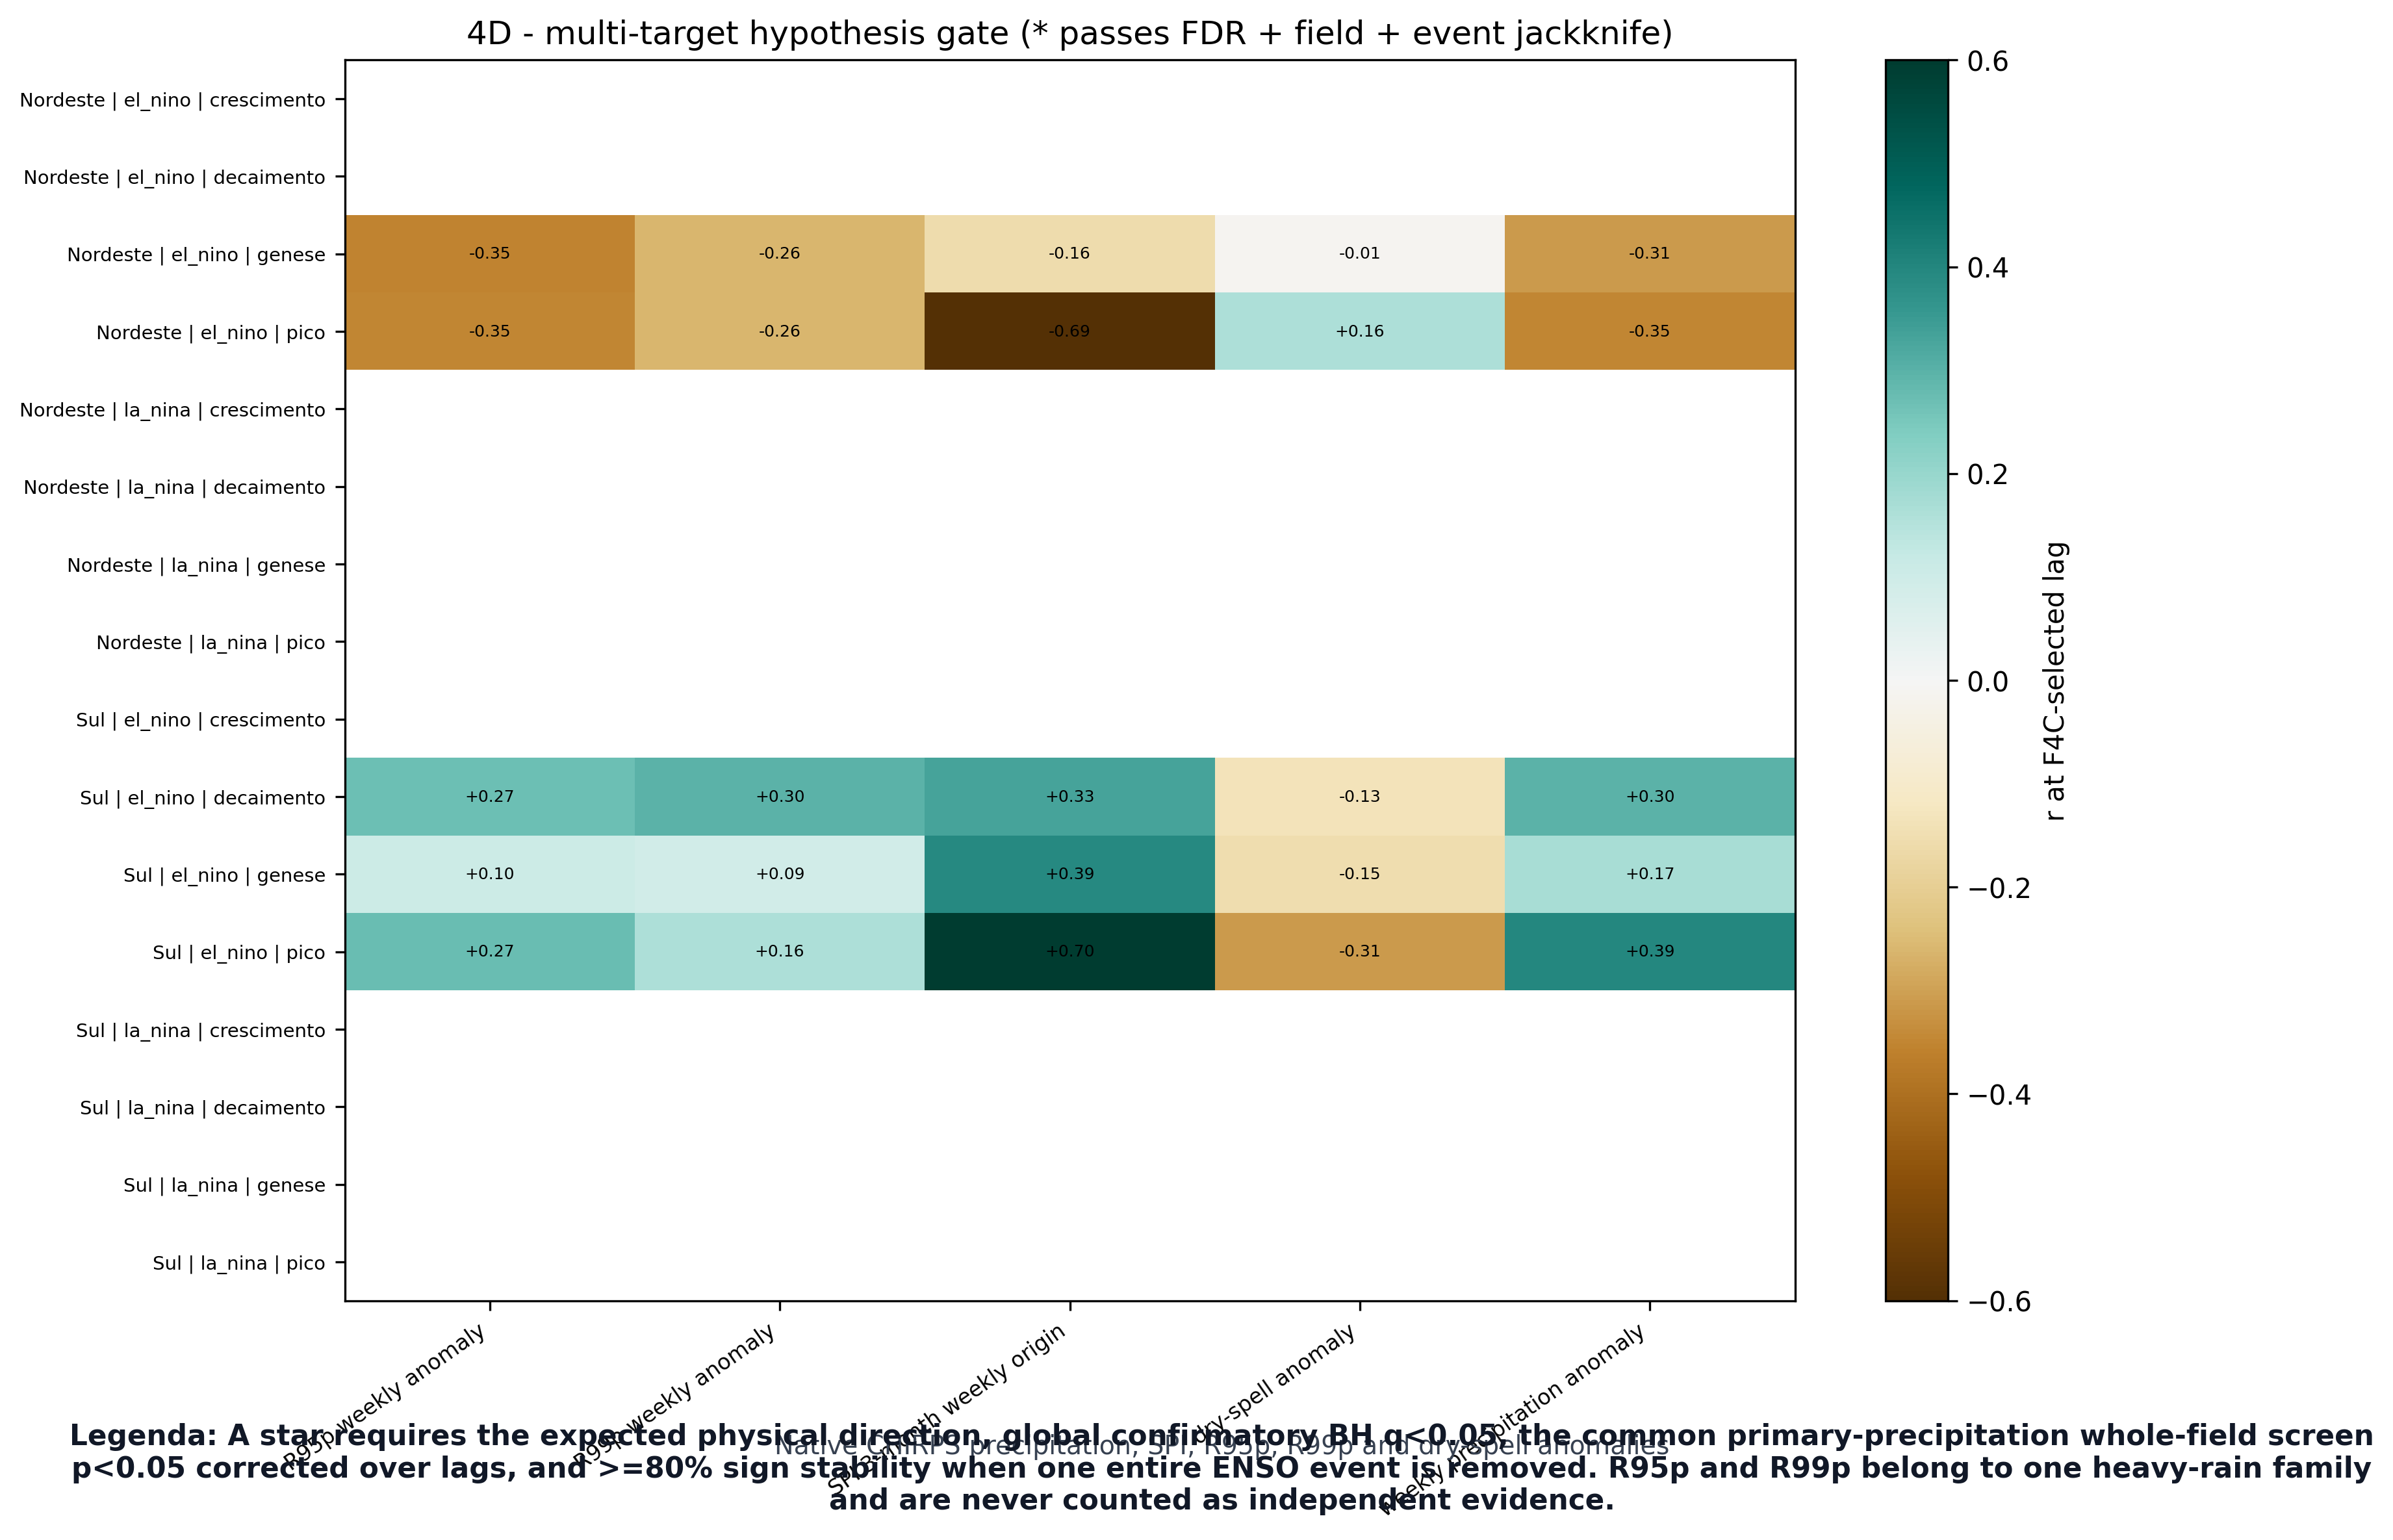

In [4]:
if run_id_4d is not None:
    figures = sorted(FIGS.glob('Fig_4D*.png'))
    if not figures:
        print('Nenhuma figura F4D canônica registrada para o run validado.')
    for figure in figures:
        print(figure.name)
        display(Image(filename=str(figure)))


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Grimm, A. M., & Tedeschi, R. G. (2009). ENSO and Extreme Rainfall Events in South America. *J. Climate*, 22, 1589-1609. https://doi.org/10.1175/2008JCLI2429.1
2. Cai, W., et al. (2020). Climate impacts of ENSO on South America. *Nat. Rev. Earth Environ.*, 1, 215-231. https://doi.org/10.1038/s43017-020-0040-3
3. Vicente-Serrano, S. M., et al. (2010). SPEI. *J. Climate*, 23, 1696-1718. https://doi.org/10.1175/2009JCLI2909.1

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.